phase 12 clustering (unsupervised learning)

In [49]:
import pandas as pd 
df=pd.read_csv("/workspaces/cyber-threat-log-analyzer/data/Global_Cybersecurity_Threats_2015-2024.csv")

In [50]:
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   str    
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   str    
 3   Target Industry                      3000 non-null   str    
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   str    
 7   Security Vulnerability Type          3000 non-null   str    
 8   Defense Mechanism Used               3000 non-null   str    
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 234.5 KB


In [52]:
df.isnull().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [53]:
#selected numerical features 
features = [

"Financial Loss (in Million $)",

"Number of Affected Users",

"Incident Resolution Time (in Hours)"

]

X = df[features]

X.head()

,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
0,80.53,773169,63
1,62.19,295961,71
2,38.65,605895,20
3,41.44,659320,7
4,74.41,810682,68


In [54]:
#feature scaling 
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled= scaler.fit_transform(X)

In [55]:
print(X_scaled.shape)

(3000, 3)


In [56]:
#feature 12.3 
from sklearn.cluster import KMeans 
kmeans= KMeans(
    n_clusters=3,
    random_state=42
)

In [57]:
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 3)","[

In [58]:
#cluster labels
labels=kmeans.labels_
print(labels)

[1 0 2 ... 2 0 0]


In [59]:
#cluster centres 
print(kmeans.cluster_centers_)

[[ 0.08986361 -1.05149354 -0.00521458]
 [ 0.89186337  0.69824984 -0.00475486]
 [-0.99092305  0.55520224  0.01090136]]


In [60]:
df["Cluster"]= labels
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Cluster
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63,1
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71,0
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20,2
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7,2
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68,1


In [61]:
print(df["Cluster"].value_counts())

Cluster
0    1119
2     946
1     935
Name: count, dtype: int64


In [62]:
#feature 12.4 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

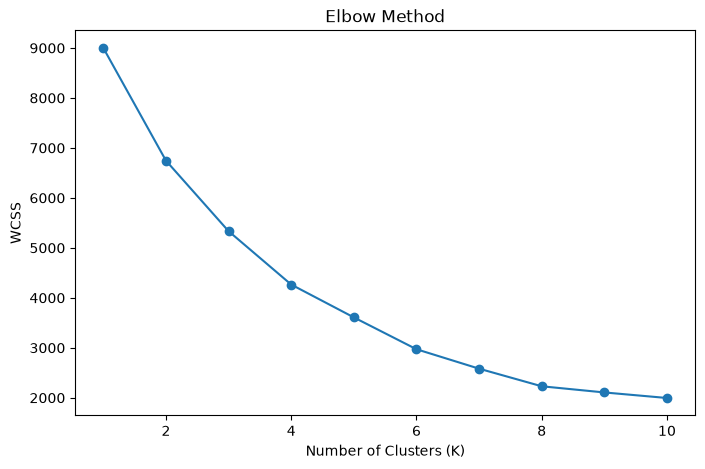

In [63]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.show()

In [64]:
print(X_plot_scaled.shape)
print(labels.shape)

(3000, 2)
(3000,)


In [65]:
#feature 12.5 visualizing clusters 
X_plot = df[[
    "Financial Loss (in Million $)",
    "Number of Affected Users"
]]

In [66]:
scaler = StandardScaler()

X_plot_scaled = scaler.fit_transform(X_plot)

In [67]:
Kmeans=KMeans(
    n_clusters=3,
    random_state=42
)

labels=kmeans.fit_transform(X_plot_scaled)

In [71]:
#feature 12.6 hierarchaical clustering 
from sklearn.cluster import AgglomerativeClustering

In [72]:
agg_cluster = AgglomerativeClustering(
    n_clusters=3
)

labels = agg_cluster.fit_predict(X_plot_scaled)

In [73]:
print(labels[:20])

[2 0 2 2 2 0 1 2 1 2 0 1 1 2 1 0 1 2 1 0]


In [75]:
import numpy as np

unique, counts = np.unique(labels, return_counts=True)

print(unique)
print(counts)

[0 1 2]
[1416  743  841]


In [76]:
#Feature 12.7 — DBSCAN
from sklearn.cluster import DBSCAN

In [91]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

In [92]:
labels = dbscan.fit_predict(X_plot_scaled)

In [93]:
print(labels[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [94]:
import numpy as np

unique, counts = np.unique(labels, return_counts=True)

print(unique)
print(counts)

[0]
[3000]


In [95]:
#Feature 12.8 — Evaluating Clustering (Silhouette Score)
from sklearn.metrics import silhouette_score

DBSCAN may produce only one cluster if eps and min_samples are not appropriate for the dataset. In such cases, the Silhouette Score cannot be computed because it requires at least two clusters.

In [96]:
score = silhouette_score(
    X_plot_scaled,
    labels
)

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [90]:
print(np.unique(labels, return_counts=True))

(array([0]), array([3000]))


In [97]:
#Feature 12.9 — Principal Component Analysis (PCA)
from sklearn.decomposition import PCA


In [98]:
pca = PCA(n_components=1)

In [99]:
X_pca = pca.fit_transform(X_plot_scaled)

In [100]:
print(X_plot_scaled.shape)
print(X_pca.shape)

(3000, 2)
(3000, 1)


In [101]:
print(pca.explained_variance_ratio_)

[0.50089337]


In [102]:
#Feature 12.10 — Choosing the Number of Principal Components
pca = PCA()

In [103]:
pca.fit(X_plot_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [104]:
print(pca.explained_variance_ratio_)

[0.50089337 0.49910663]


In [105]:
import numpy as np

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(cumulative_variance)

[0.50089337 1.        ]


In [106]:
pca = PCA(n_components=0.95)

X_reduced = pca.fit_transform(X_plot_scaled)

print(X_reduced.shape)

(3000, 2)
